# Стратегия взаимодействия с клиентами сетевого провайдера

Исходные данные: сведения о клиентах сетевого провайдера.

Цели проекта:

* спрогнозировать вероятность оттока каждого клиента сетевого провайдера;
* выявить основные факторы, влияющие на отток клиентов, и сформировать портреты лояльных клиентов и склонных к оттоку;
* дать рекомендации по повышению качества работы с клиентами и снижению оттока.

In [63]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.preprocessing import StandardScaler
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.cluster import KMeans
from sklearn.preprocessing import OneHotEncoder
from xgboost import XGBClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV

pd.set_option('display.max_columns', None)
sns.set_style('whitegrid')
sns.set_palette("Paired")

## Загрузка и предобработка данных

In [87]:
df = pd.read_csv('/content/WA_Fn-UseC_-Telco-Customer-Churn.csv')
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [88]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


Видим, что пустых значений нет. Переименуем столбцы для удобства работы.

In [89]:
df.columns = ['customer_id', 'gender', 'senior_citizen', 'partner', 'dependents',
              'tenure', 'phone_service', 'multiple_lines', 'internet_service',
              'online_security', 'online_backup', 'device_protection', 'tech_support',
              'streaming_tv', 'streaming_movies', 'contract', 'paperless_billing', 'payment_method',
              'monthly_charges', 'total_charges', 'churn']

Посмотрим распределения всех признаков.

In [90]:
df.describe(include='all')

,customer_id,gender,senior_citizen,partner,dependents,tenure,phone_service,multiple_lines,internet_service,online_security,online_backup,device_protection,tech_support,streaming_tv,streaming_movies,contract,paperless_billing,payment_method,monthly_charges,total_charges,churn
count,7043,7043,7043.000000,7043,7043,7043.000000,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043.000000,7043,7043
unique,7043,2,NaN,2,2,NaN,2,3,3,3,3,3,3,3,3,3,2,4,NaN,6531,2
top,3186-AJIEK,Male,NaN,No,No,NaN,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,NaN,,No
freq,1,3555,NaN,3641,4933,NaN,6361,3390,3096,3498,3088,3095,3473,2810,2785,3875,4171,2365,NaN,11,5174
mean,NaN,NaN,0.162147,NaN,NaN,32.371149,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,64.761692,NaN,NaN
std,NaN,NaN,0.368612,NaN,NaN,24.559481,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,30.090047,NaN,NaN
min,NaN,NaN,0.000000,NaN,NaN,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,18.250000,NaN,NaN
25%,NaN,NaN,0.000000,NaN,NaN,9.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,35.500000,NaN,NaN
50%,NaN,NaN,0.000000,NaN,NaN,29.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,70.350000,NaN,NaN
75%,NaN,NaN,0.000000,NaN,NaN,55.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,89.850000,NaN,NaN


Видим, что в признаке total_charges есть значение в виде пробела. Посмотрим на строки с таким значением.

In [91]:
df[df['total_charges'] == ' ']

,customer_id,gender,senior_citizen,partner,dependents,tenure,phone_service,multiple_lines,internet_service,online_security,online_backup,device_protection,tech_support,streaming_tv,streaming_movies,contract,paperless_billing,payment_method,monthly_charges,total_charges,churn
488,4472-LVYGI,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,No,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,,No
753,3115-CZMZD,Male,0,No,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,,No
936,5709-LVOEQ,Female,0,Yes,Yes,0,Yes,No,DSL,Yes,Yes,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,,No
1082,4367-NUYAO,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,,No
1340,1371-DWPAZ,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,Yes,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,,No
3331,7644-OMVMY,Male,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,,No
3826,3213-VVOLG,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,,No
4380,2520-SGTTA,Female,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,,No
5218,2923-ARZLG,Male,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,,No
6670,4075-WKNIU,Female,0,Yes,Yes,0,Yes,Yes,DSL,No,Yes,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,,No


Видим, что это нормальные записи новых клиентов, которые недавно (меньше месяца) обратились за услугами компании (значение tenure равно 0). Вероятно, оплата ещё не прошла, поэтому заменим пробел на 0.

In [92]:
df['total_charges'] = df['total_charges'].replace(' ', 0).astype(float)

Проверим наличие дубликатов

In [93]:
df.duplicated().sum()

np.int64(0)

Дубликатов нет.

Бинарные признаки преобразуем из формата строк в числовой формат.

In [94]:
gender_mapping = {'Female': 1, 'Male': 0}
df['gender'] = df['gender'].map(gender_mapping)

bin_cols = ['partner', 'dependents',
       'phone_service', 'paperless_billing', 'churn']
mapping = {'Yes': 1, 'No': 0}
for col in bin_cols:
  df[col] = df[col].map(mapping)


* Нет пустых значений в данных
* Произведена замена значения пробела total_charges на 0
* Приведение бинарных признаков из строкового в числовой формат

## Анализ данных

### Построим круговую диаграмму распределения доли активных и ушедших клиентов

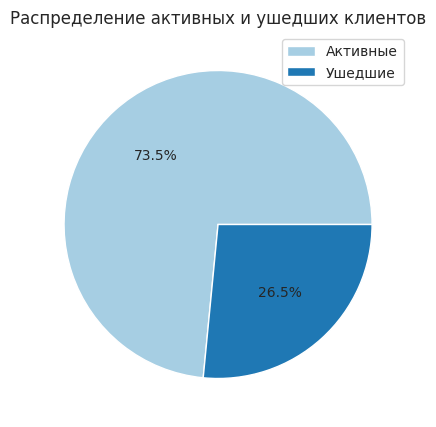

In [95]:
churn = df.groupby('churn').agg({'customer_id':'nunique'}).reset_index()
churn.columns = ['churn', 'n_users']

plt.figure(figsize=(5, 5))
plt.pie(x=churn['n_users'], autopct='%1.1f%%')
plt.title('Распределение активных и ушедших клиентов')
plt.legend(['Активные', 'Ушедшие'])
plt.show()

По круговой диаграмме видим, что доля ушедших составляет 26.5%

### Построим распределения числовых непрерывных признаков

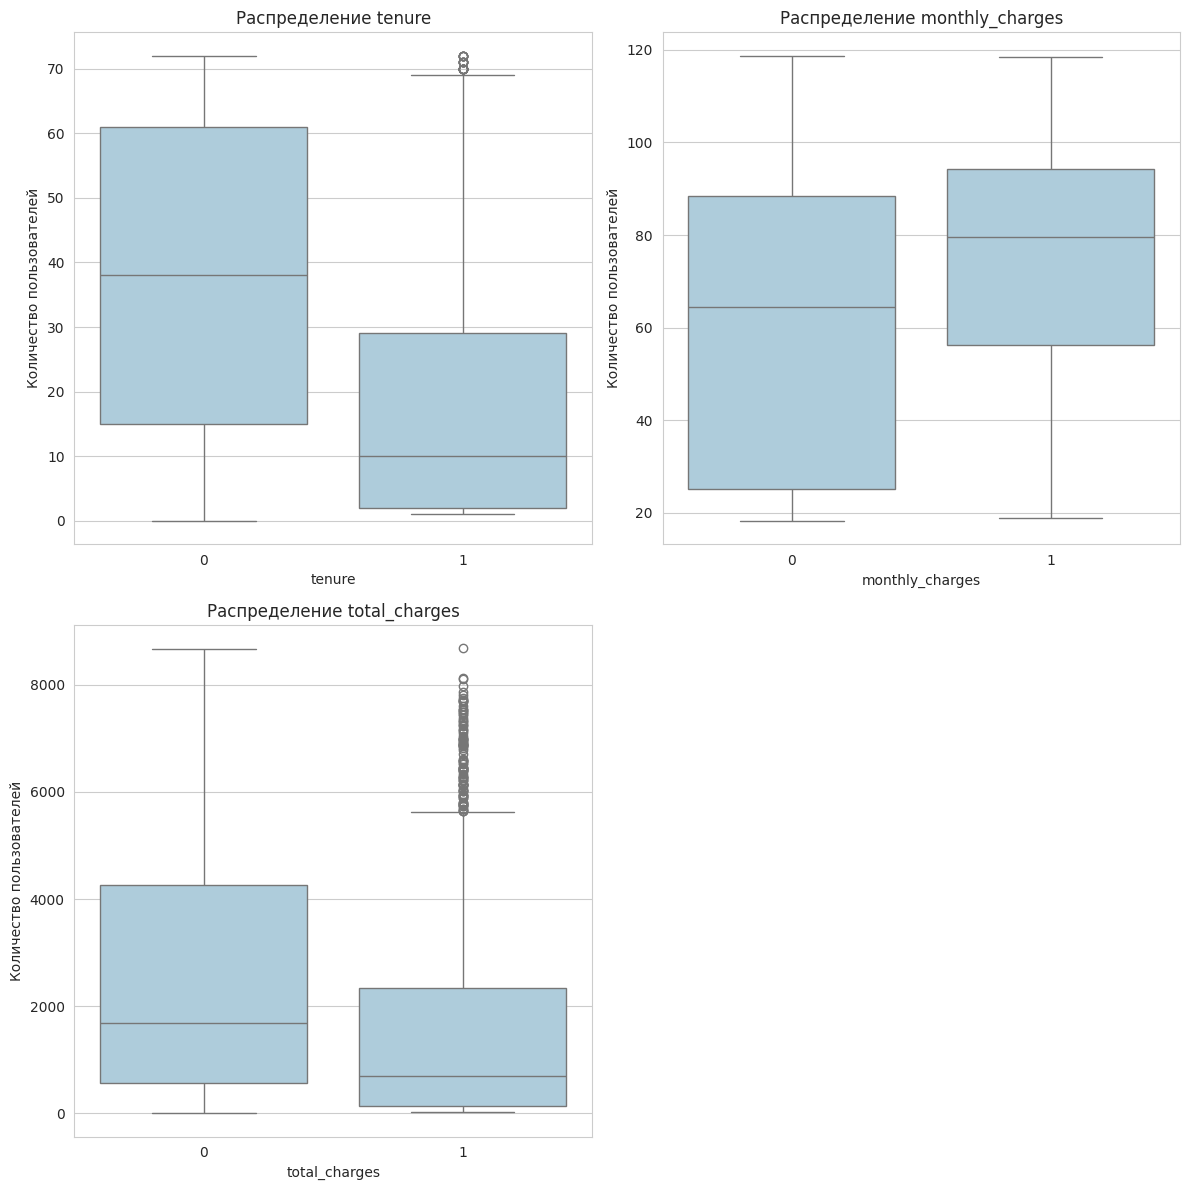

In [96]:
num_columns = ['tenure', 'monthly_charges', 'total_charges']
plt.figure(figsize=(12, 12))

for i in range(1, len(num_columns) + 1):
  plt.subplot(2, 2, i)
  sns.boxplot(data=df, x='churn', y=num_columns[i - 1])
  plt.title(f'Распределение {num_columns[i - 1]}')
  plt.xlabel(f'{num_columns[i - 1]}')
  plt.ylabel('Количество пользователей')

plt.tight_layout()
plt.show()

Распределение количества месяцев для активных пользователей приближенно к нормальному (среднее ~38), для ушедших - скошено вправо, то есть большинство клиентов имеют более короткий период пользования, чем активные клиенты (среднее 10), однако имеются выбросы с очень длительным периодом в месяц.

По графику распределения месячной платы видим, что для активных клиентов стоимость в среднем ниже, чем для ушедших.

Распределение общей суммы оплат показывает, что для активных пользователей среднее значение (около 1600) выше, чем у ушедших клиентов (около 900), также наблюдаем множество выбросов с большими значениями для ушедших клиентов.

### Поcтроим столбчатые диаграммы для бинарных и категориальных признаков

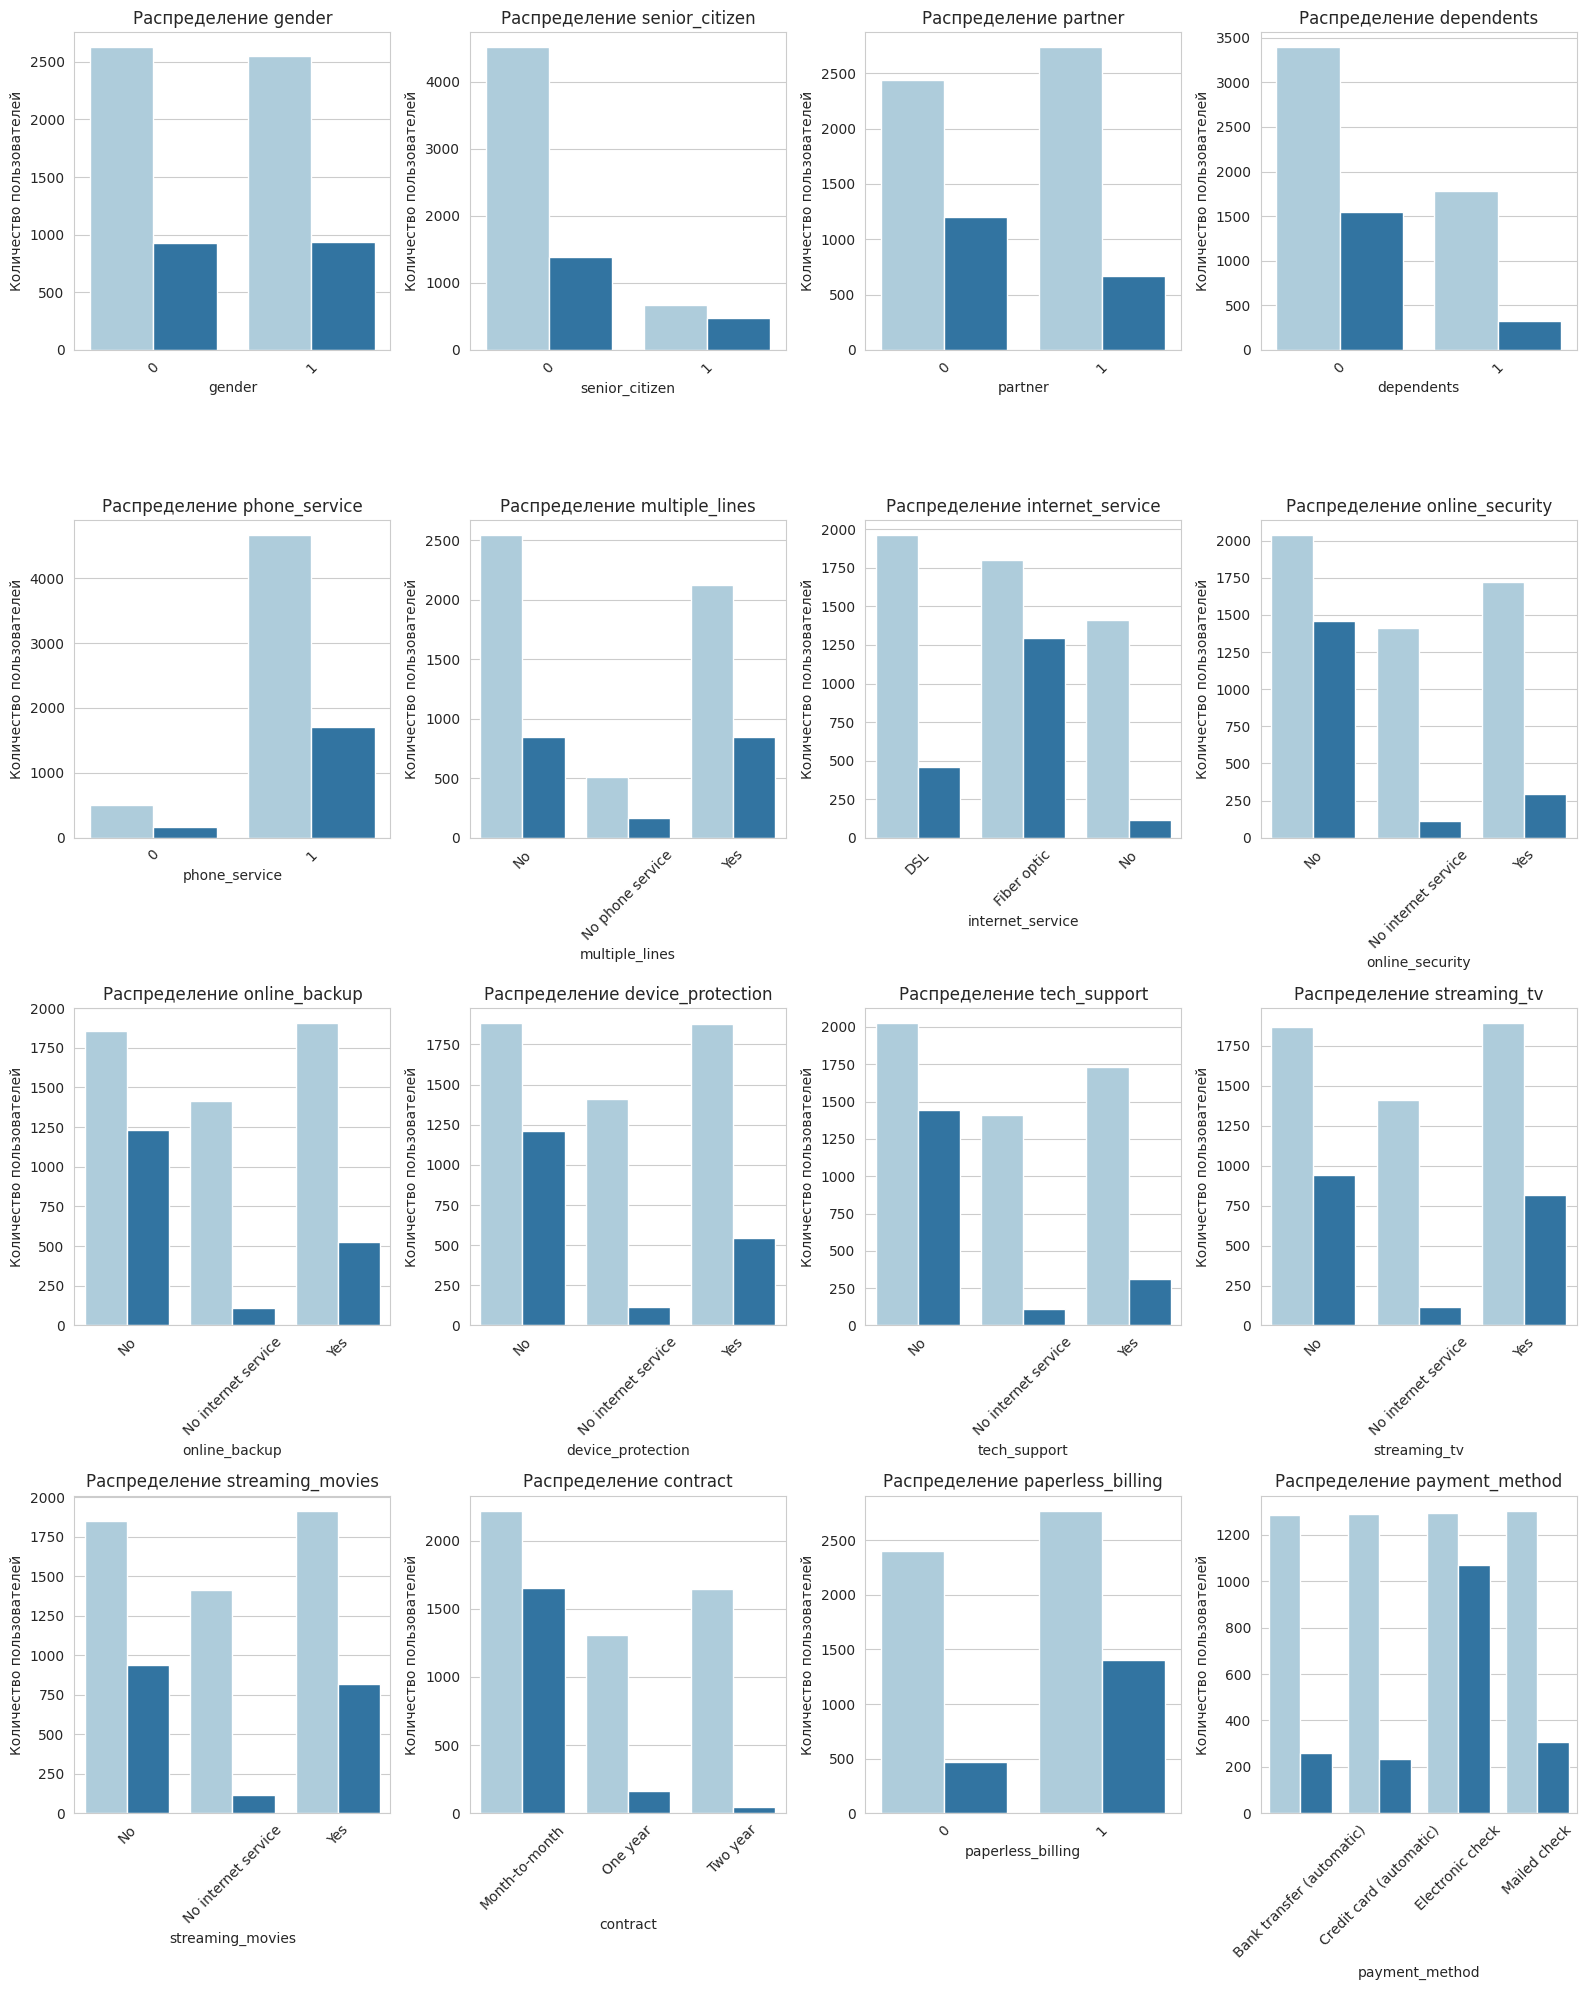

In [97]:
cat_columns = ['gender', 'senior_citizen', 'partner', 'dependents',
       'phone_service', 'multiple_lines', 'internet_service',
       'online_security', 'online_backup', 'device_protection', 'tech_support',
       'streaming_tv', 'streaming_movies', 'contract', 'paperless_billing',
       'payment_method']

plt.figure(figsize=(16, 20))

for i in range(1, len(cat_columns) + 1):
  cat_col =  df.groupby([cat_columns[i - 1], 'churn']).agg({'customer_id':'nunique'}).reset_index()
  cat_col.columns = [cat_columns[i - 1], 'churn', 'n_users']

  plt.subplot(4, 4, i)
  ax = sns.barplot(data=cat_col, x=cat_columns[i - 1],
              y='n_users', hue='churn', legend=False)
  plt.title(f'Распределение {cat_columns[i - 1]}')
  plt.xlabel(f'{cat_columns[i - 1]}')
  plt.xticks(rotation=45)
  plt.ylabel('Количество пользователей')


plt.tight_layout()
plt.show()

По графикам видим, что в среднем активный клиент выглядит так:
* непожилой человек
* состоит в отношениях
* без иждевенцев
* с подключенными мобильным сервисом, DSL интернет сервисом
* без подключения сервиса множества мобильных линий, онлайн безопасности, технической поддержки
* проводящий помесячную оплату

Для ушедших клиентов характерно:
* непожилой возраст
* без пары и иждевенцев
* с подключенным мобильным сервисом и оптоволоконным интернет-сервисом
* без подключения дополнительных услуг (онлайн-безопасности, онлайн-бэкапа, защиты устройств и других)
* ежемесячная оплата с помощью электоронного чека

### Построим корреляционную матрицу по числовым признакам

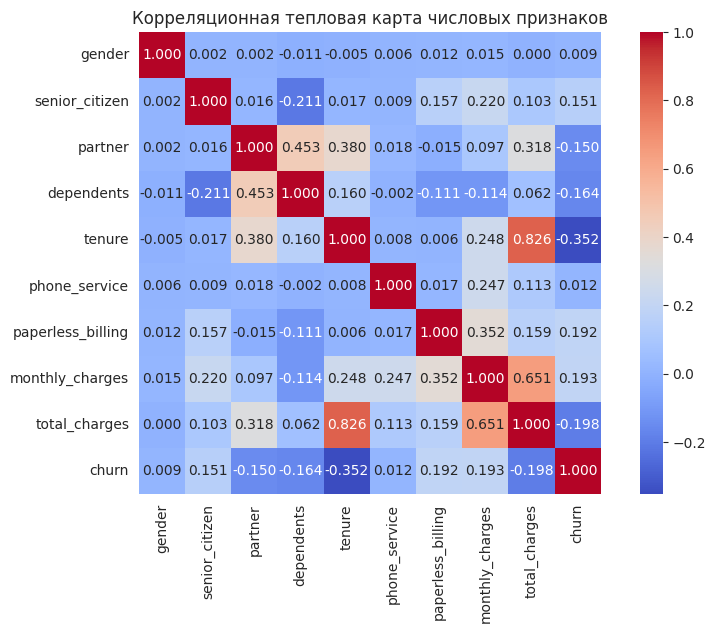

In [98]:
numeric_cols = df.select_dtypes(include=np.number).columns.tolist()

plt.figure(figsize=(10,6))
sns.heatmap(df[numeric_cols].corr(), annot=True, cmap='coolwarm', fmt='.3f', square=True)
plt.title("Корреляционная тепловая карта числовых признаков")
plt.show()

По матрице корреляции видим, что корреляции умеренная между: partner и dependents, сильная между: monthly_charges и total_charges, очень сильная между: tenure и total_charges. Для исключения мультиколлениарности удалим признак total_charges

In [76]:
df = df.drop('total_charges', axis=1)

## Построение и обучение моделей

Подготовим данные, преобразовав категориальные признаки с помощью OneHotEncoder

In [77]:
df = df.drop('customer_id', axis=1)
cat_columns = ['multiple_lines', 'internet_service',
       'online_security', 'online_backup', 'device_protection', 'tech_support',
       'streaming_tv', 'streaming_movies', 'contract', 'payment_method']

ohe = OneHotEncoder(sparse_output=False)
encoded_cat_columns = pd.DataFrame(ohe.fit_transform(df[cat_columns]), columns=ohe.get_feature_names_out())

df = df.drop(columns=cat_columns)
df = pd.concat([df, encoded_cat_columns], axis=1)

Создадим функцию для обучения модели и предсказания оттока. Будем использовать следубщие метрики:
* accurancy (общая доля правильных ответов)
* precision (сколько среди предсказанных ушедших отпределны правильно)
* recall (сколько среди реально ушедших предсказано)
* ROC-AUC (способность различать классы)

In [78]:
def make_prediction(m, X_train, y_train, X_test, y_test):
    model = m
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    print('* Accuracy: {:.3f}'.format(accuracy_score(y_test, y_pred)))
    print('* Precision: {:.3f}'.format(precision_score (y_test, y_pred)))
    print('* Recall: {:.3f}'.format(recall_score(y_test, y_pred)))
    print('* ROC-AUC: {:.3f}'.format(roc_auc_score(y_test, y_pred)))

Выделим параметры и целевой признак в отдельные датафреймы. Разделим данные на тренировочные и тестовые. Выберем для обучения несколько реализованных моделей.

In [79]:
X = df.drop(['churn'], axis = 1)
y = df['churn']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)

models = [
    LogisticRegression(max_iter=1000, random_state=0),
    RandomForestClassifier(random_state=0),
    XGBClassifier(random_state=0),
    GradientBoostingClassifier(random_state=0)
]

In [80]:
for i in models:
    print(i)
    make_prediction(i, X_train, y_train, X_test, y_test)

LogisticRegression(max_iter=1000, random_state=0)
* Accuracy: 0.798
* Precision: 0.639
* Recall: 0.519
* ROC-AUC: 0.708
RandomForestClassifier(random_state=0)
* Accuracy: 0.769
* Precision: 0.574
* Recall: 0.440
* ROC-AUC: 0.662
XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=None, num_parallel_tree=None, ...)
* Accuracy

Наилучший результат показала модель логистической регрессии (accurancy = 0.798).

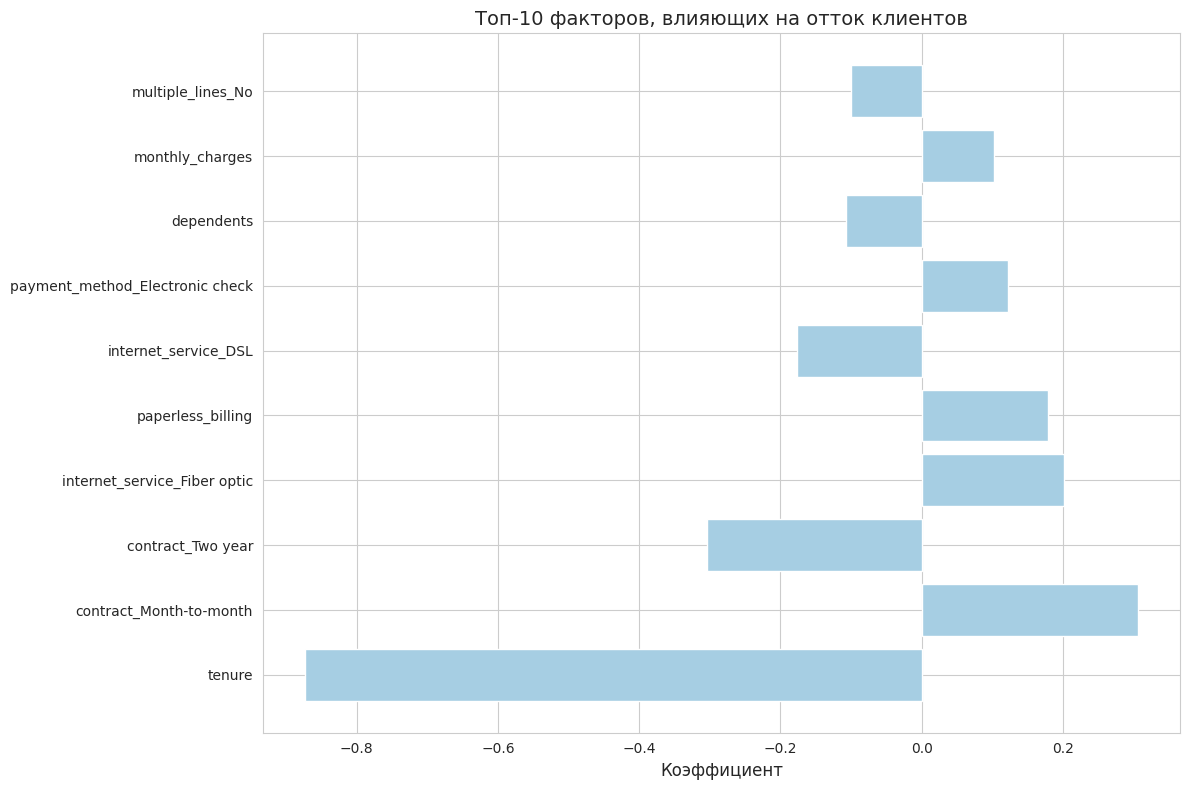

In [81]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

best_model = LogisticRegression(max_iter=1000, random_state=0)
best_model.fit(X_train_scaled, y_train)

feature_importance = pd.DataFrame({
    'feature': X.columns,
    'coefficient': best_model.coef_[0],
    'abs_coefficient': np.abs(best_model.coef_[0])
}).sort_values('abs_coefficient', ascending=False)

plt.figure(figsize=(12, 8))
top_features = feature_importance.head(10)
bars = plt.barh(range(len(top_features)), top_features['coefficient'])
plt.yticks(range(len(top_features)), top_features['feature'])
plt.xlabel('Коэффициент', fontsize=12)
plt.title('Топ-10 факторов, влияющих на отток клиентов', fontsize=14)

plt.tight_layout()
plt.show()

Видим, что наибольшую связь с оттоком имеют: длительность пользования услугами (обратная связь), ежемесячная оплата, оплата раз в два года (обратная связь) и выбор оптоволокна как интернет сервиса.

## Кластеризация клиентов

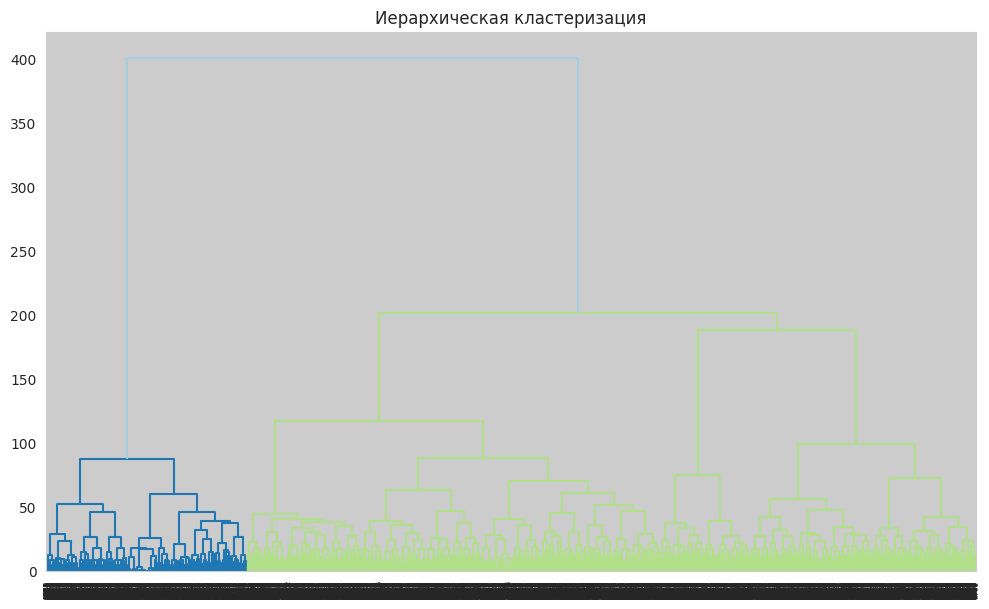

In [85]:
from scipy.cluster.hierarchy import dendrogram, linkage

sc = StandardScaler()
x_sc = sc.fit_transform(df.drop('churn', axis = 1))

linked = linkage(x_sc, method = 'ward')

plt.figure(figsize=(12, 7))
dendrogram(linked, orientation='top')
plt.title('Иерархическая кластеризация')
plt.show()

На основании полученного графика можно предположить, что в данных можно выделить 2 кластера.

Теперь обучим модель кластеризации на основании алгоритма K-Means и спрогнозируем кластеры клиентов. За число кластеров примем n=3, что согласуется с построенной дендрограммой.

In [83]:
from sklearn.cluster import KMeans
km = KMeans(n_clusters = 3, random_state=0)

labels = km.fit_predict(x_sc)

df['cluster_client'] = labels

clasters = df.groupby(['cluster_client']).mean()
clasters

,gender,senior_citizen,partner,dependents,tenure,phone_service,paperless_billing,monthly_charges,churn,multiple_lines_No,multiple_lines_No phone service,multiple_lines_Yes,internet_service_DSL,internet_service_Fiber optic,internet_service_No,online_security_No,online_security_No internet service,online_security_Yes,online_backup_No,online_backup_No internet service,online_backup_Yes,device_protection_No,device_protection_No internet service,device_protection_Yes,tech_support_No,tech_support_No internet service,tech_support_Yes,streaming_tv_No,streaming_tv_No internet service,streaming_tv_Yes,streaming_movies_No,streaming_movies_No internet service,streaming_movies_Yes,contract_Month-to-month,contract_One year,contract_Two year,payment_method_Bank transfer (automatic),payment_method_Credit card (automatic),payment_method_Electronic check,payment_method_Mailed check
cluster_client,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
0,0.489515,0.034076,0.483617,0.421363,30.547182,1.000000,0.292267,21.079194,0.074050,0.775885,0.000000,0.224115,0.000000,0.000000,1.0,0.000000,1.0,0.000000,0.000000,1.0,0.000000,0.000000,1.0,0.000000,0.000000,1.0,0.000000,0.000000,1.0,0.000000,0.000000,1.0,0.000000,0.343381,0.238532,0.418087,0.217562,0.216907,0.079948,0.485583
1,0.490851,0.230498,0.333868,0.176565,17.526485,0.879615,0.702087,70.118909,0.460995,0.499518,0.120385,0.380096,0.396148,0.603852,0.0,0.816693,0.0,0.183307,0.743499,0.0,0.256501,0.781701,0.0,0.218299,0.843981,0.0,0.156019,0.677368,0.0,0.322632,0.674157,0.0,0.325843,0.938684,0.053612,0.007705,0.137400,0.133547,0.539326,0.189727
2,0.504580,0.154871,0.676103,0.381765,52.781016,0.872190,0.640300,85.565924,0.133222,0.270608,0.127810,0.601582,0.494172,0.505828,0.0,0.397169,0.0,0.602831,0.321399,0.0,0.678601,0.274771,0.0,0.725229,0.351374,0.0,0.648626,0.291424,0.0,0.708576,0.285179,0.0,0.714821,0.177769,0.392173,0.430058,0.326395,0.322648,0.234388,0.116570


Видим такие 3 кластера:
1. Лояльные клиенты без подключения интернета
* более двух лет пользования услугами
* подключена только мобильная сеть
* низкий месячный платеж
* низкая процент ухода
* платеж раз в два года
* около половины оплачивает отправленным чеком
2. Группа риска
* менее двух лет пользования
* высокий месячный платеж
* высокий процент ухода
* в основном оптоволокно
* помесячная оплата
* оплата электронным чеком
3. Лояльные и платежеспособные
* более четырех лет пользования услугами
* высокий месячный платеж
* низкий процент ухода
* у большинства клиентов подключены дополнительные услуги (обеспечение безопасности, стриминг тв и другие)
* оплата раз в год или два
* у большинства автоматическая оплата

## Выводы

**Ключевые показатели:**
* Доля ушедших клиентов составляет 26,5%.
* Accuracy логистической регрессии 79,8%

Для **ушедших** клиентов характерно:
* менее двух лет пользования сервисом
* ежемесячная оплата с помощью электоронного чека
* оптоволоконный интернет-сервис
* без подключения дополнительных услуг (онлайн-безопасности, онлайн-бэкапа, защиты устройств и других)
* отсутствие пары и иждевенцев

Для **лояльных** клиентов характерно:
* более 4 лет пользования сервисом
* оплата раз в год или два
* подключеный DSL интернет-сервис
* подключение дополнительных услуг
* имеет партнера

Можно предложить несколько стратегий для удержания клиентов:
* Предложение скидки при переходе с помесячной оплаты на оплаты раз в год или два
* Внедрение пробного периода подключения дополнительных услуг
* Внедрение программы лояльности с бонусами за 1, 3, 5 лет с компанией
